In [1]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter

In [35]:
#Params
L = 1000
J = 1
g = 1
k = kb.k_vals(L)
U = kb.U(k,g)
x= np.arange(0,50,dtype=int)

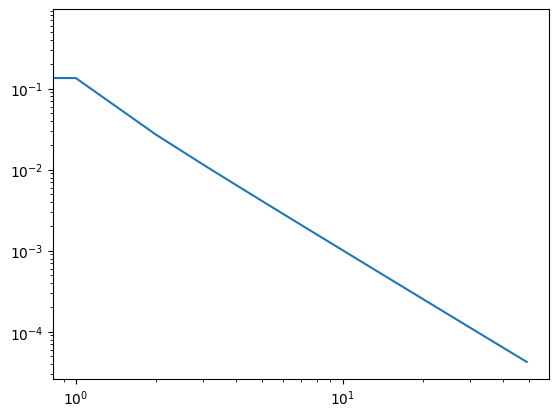

In [36]:
#plt.loglog([abs(kb.BA([U,k,l])) for l in range(30)])
plt.loglog([kb.sigma_general([0,1,li,li+1],U,k)-kb.sigma_general([0,1],U,k)**2 for li in range(0,50)])


/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/scaling_dim/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/tmp/ipykernel_3558/1899081510.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(x,x**(-1/4)*kb.sigma_general([0,1],U,k));


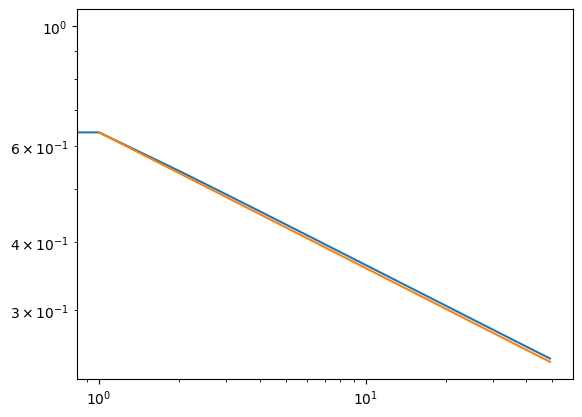

In [3]:
plt.loglog(x,[kb.sigma_general([0,xi],U,k) for xi in x]);
plt.loglog(x,x**(-1/4)*kb.sigma_general([0,1],U,k));

In [4]:
x= np.arange(0,20,dtype=int)
C_nn = np.array([[ kb.P_n_correlations(n,li,U,k, even = True)-kb.P_n(n,U,k,even=True)**2 for li in x] for n in [1,2,3,4,5,6,7,8]])

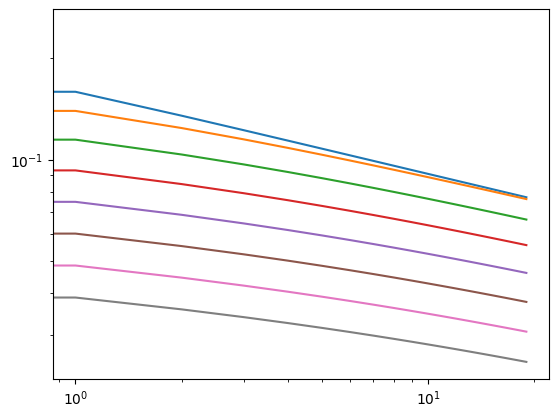

In [6]:
labels = [ f"n = {n}" for n in [1,2,3,4,5,6,7,8]]
plt.loglog(C_nn.T,label=labels)

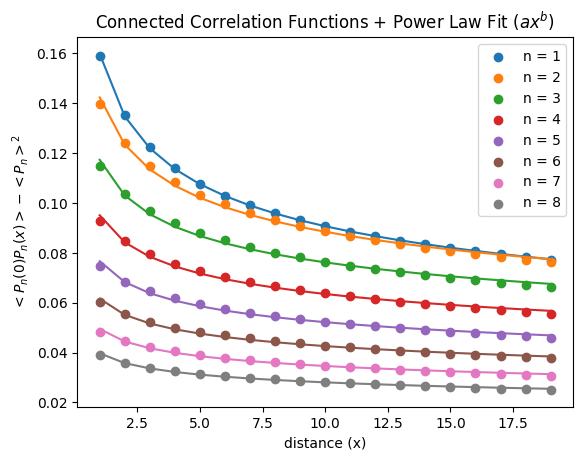

In [72]:
from scipy.optimize import curve_fit

# Power-law model
def power_func(x, a, b):
    return a * x**b
n = 8
# Exclude x=0
x= np.arange(1,20,dtype=int)
A = []
B = []
for ni in range(0,n,1):
    y = C_nn[ni,1:]  # roughly y ≈ a * x^b



    # Fit
    params, _ = curve_fit(power_func, x, y)
    a_fit, b_fit = params
    A.append(a_fit)
    B.append(b_fit)

    plt.scatter(x,y, label = f"n = {ni+1}")
    plt.plot(x,a_fit*x**b_fit)#,label=f"Fit (b = {str(b_fit)[:5]})")
    plt.legend()
    plt.xlabel("distance (x)")
    plt.ylabel(r"$< P_n(0) P_n(x) >- <P_n>^2$")
    plt.title(r"Connected Correlation Functions + Power Law Fit $(ax^b)$")
B = np.array(B)
#plt.figure()
#plt.scatter(np.arange(n)+1,-B)
plt.savefig("Pnscaling_nofits.png")

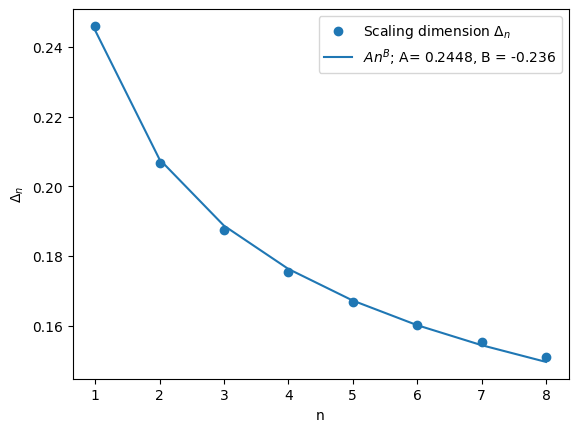

In [70]:
plt.scatter(np.arange(n)+1,-B,label=r"Scaling dimension $\Delta_n$")
params, _ = curve_fit(power_func, np.arange(n)+1, -B)
a_fit, b_fit = params
plot(np.arange(n)+1,a_fit*(np.arange(n)+1)**b_fit,label=fr"$An^B$; A= {str(a_fit)[:6]}, B = {str(b_fit)[:6]}")
# plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.ylabel(r"$\Delta_n$")
plt.xlabel("n")
plt.savefig("Scaling_dimension_vs_n.png")

In [16]:
b_fit

np.float64(-0.2369041912947879)